# Phase 2 — E1: Visualise beam-search predictions with BLEU-n highlighting

A 4×4 grid of test images. Each panel shows the image, the first reference
caption, and the model's prediction. Each predicted word is coloured by the
**highest** n for which an n-gram containing that word matches **some**
reference caption (unclipped match — pure visualisation, not the BLEU
scoring procedure).

* BLEU-4 match → dark green
* BLEU-3 match → green
* BLEU-2 match → orange
* BLEU-1 match → red
* no match    → grey

When a word participates in both a BLEU-1 and BLEU-2 match the higher tier
wins, so a word is shown in at most one colour.

In [1]:
import ast
import random
from pathlib import Path

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import transforms as mtrans

SRC = Path("output/phase2_results/phase2_e1_beam_w5_lp0.7/test_predictions.csv")
IMG_DIR = Path("data/val")
OUT_PNG = Path("output/phase2_results/phase2_e1_viz_grid.png")

assert SRC.exists(), f"Missing {SRC} — run E1 first."
assert IMG_DIR.exists(), f"Missing {IMG_DIR} — extract data/val.zip first."

df = pd.read_csv(SRC)
# `references` column is a stringified Python list; eval it back to list[str]
df["references"] = df["references"].apply(ast.literal_eval)
print(f"Loaded {len(df)} test predictions")
df.head(3)

Loaded 1163 test predictions


,image_id,file_name,prediction,references
0,23436,VizWiz_val_00000005.jpg,quality issues are too severe to recognize vis...,[a dell laptop computer screen showing window ...
1,23438,VizWiz_val_00000007.jpg,quality issues are too severe to recognize vis...,[quality issues are too severe to recognize vi...
2,23453,VizWiz_val_00000022.jpg,a person is holding a bottle with a pink cap,[a bright colored pillow case with a bottle an...


## Per-word BLEU-n level

In [2]:
def word_match_levels(pred_words: list[str], ref_lists: list[list[str]]) -> list[int]:
    """For each predicted word, return the highest n ∈ {0,1,2,3,4} such that an
    n-gram containing that word matches some reference. 0 = no match."""
    levels = [0] * len(pred_words)
    for n in (1, 2, 3, 4):
        # All n-grams in *any* reference, as a set for O(1) lookup
        ref_ngrams = set()
        for ref in ref_lists:
            for i in range(len(ref) - n + 1):
                ref_ngrams.add(tuple(ref[i:i + n]))
        # Scan predicted n-grams
        for i in range(len(pred_words) - n + 1):
            if tuple(pred_words[i:i + n]) in ref_ngrams:
                for j in range(i, i + n):
                    if n > levels[j]:
                        levels[j] = n
    return levels


def best_reference_index(pred_words: list[str], ref_lists: list[list[str]]) -> int:
    """Return the index of the reference with the strongest n-gram overlap to
    `pred_words` (weighting longer n-grams more: n=1 → +1, n=2 → +2, …)."""
    best_idx, best_score = 0, -1
    for i, ref in enumerate(ref_lists):
        score = 0
        for n in (1, 2, 3, 4):
            ref_ngs = set(tuple(ref[j:j + n]) for j in range(len(ref) - n + 1))
            for j in range(len(pred_words) - n + 1):
                if tuple(pred_words[j:j + n]) in ref_ngs:
                    score += n  # longer matches count more
        if score > best_score:
            best_score = score; best_idx = i
    return best_idx


LEVEL_COLOR = {
    0: "#9e9e9e",  # grey   — no match
    1: "#d32f2f",  # red    — BLEU-1
    2: "#f57c00",  # orange — BLEU-2
    3: "#388e3c",  # green  — BLEU-3
    4: "#1b5e20",  # dark green — BLEU-4
}

# Quick sanity check
pred = "a can of black beans on a kitchen counter".split()
refs = [
    "a can of food sitting on a kitchen table top".split(),
    "a can of soup is right on top of the counter".split(),
    "a can of food is sitting on a counter".split(),
]
levels = word_match_levels(pred, refs)
for w, lv in zip(pred, levels):
    print(f"  {w:10s}  BLEU-{lv}" if lv > 0 else f"  {w:10s}  -")

  a           BLEU-3
  can         BLEU-3
  of          BLEU-3
  black       -
  beans       -
  on          BLEU-3
  a           BLEU-3
  kitchen     BLEU-3
  counter     BLEU-1


## Rainbow-text helper (matplotlib stdlib recipe)

Each predicted word is drawn as its own `ax.text()`; we use
`transforms.offset_copy` to chain them horizontally so they sit on one
baseline regardless of word width.

In [3]:
def colored_words_centered(ax, words, colors, fontsize=12, max_chars_per_line=40):
    """Fill `ax` with coloured words, wrapped and centered. Uses HPacker per
    line and VPacker to stack, anchored to the axes centre."""
    from matplotlib.offsetbox import TextArea, HPacker, VPacker, AnnotationBbox

    # Word-wrap on cumulative character length
    lines: list[list[tuple[str, str]]] = [[]]
    cur_len = 0
    for w, c in zip(words, colors):
        if cur_len + len(w) + 1 > max_chars_per_line and lines[-1]:
            lines.append([])
            cur_len = 0
        lines[-1].append((w, c))
        cur_len += len(w) + 1

    hpackers = []
    for line in lines:
        areas = [TextArea(w, textprops=dict(color=c, fontsize=fontsize, weight="bold"))
                 for w, c in line]
        hpackers.append(HPacker(children=areas, align="baseline", pad=0, sep=4))
    box = VPacker(children=hpackers, align="center", pad=0, sep=4)
    ab = AnnotationBbox(
        box, (0.5, 0.5), xycoords="axes fraction",
        box_alignment=(0.5, 0.5), frameon=False, pad=0,
    )
    ax.add_artist(ab)
    ax.set_axis_off()

## Pick 16 examples and render the grid

Saved output/phase2_results/phase2_e1_viz_grid.png


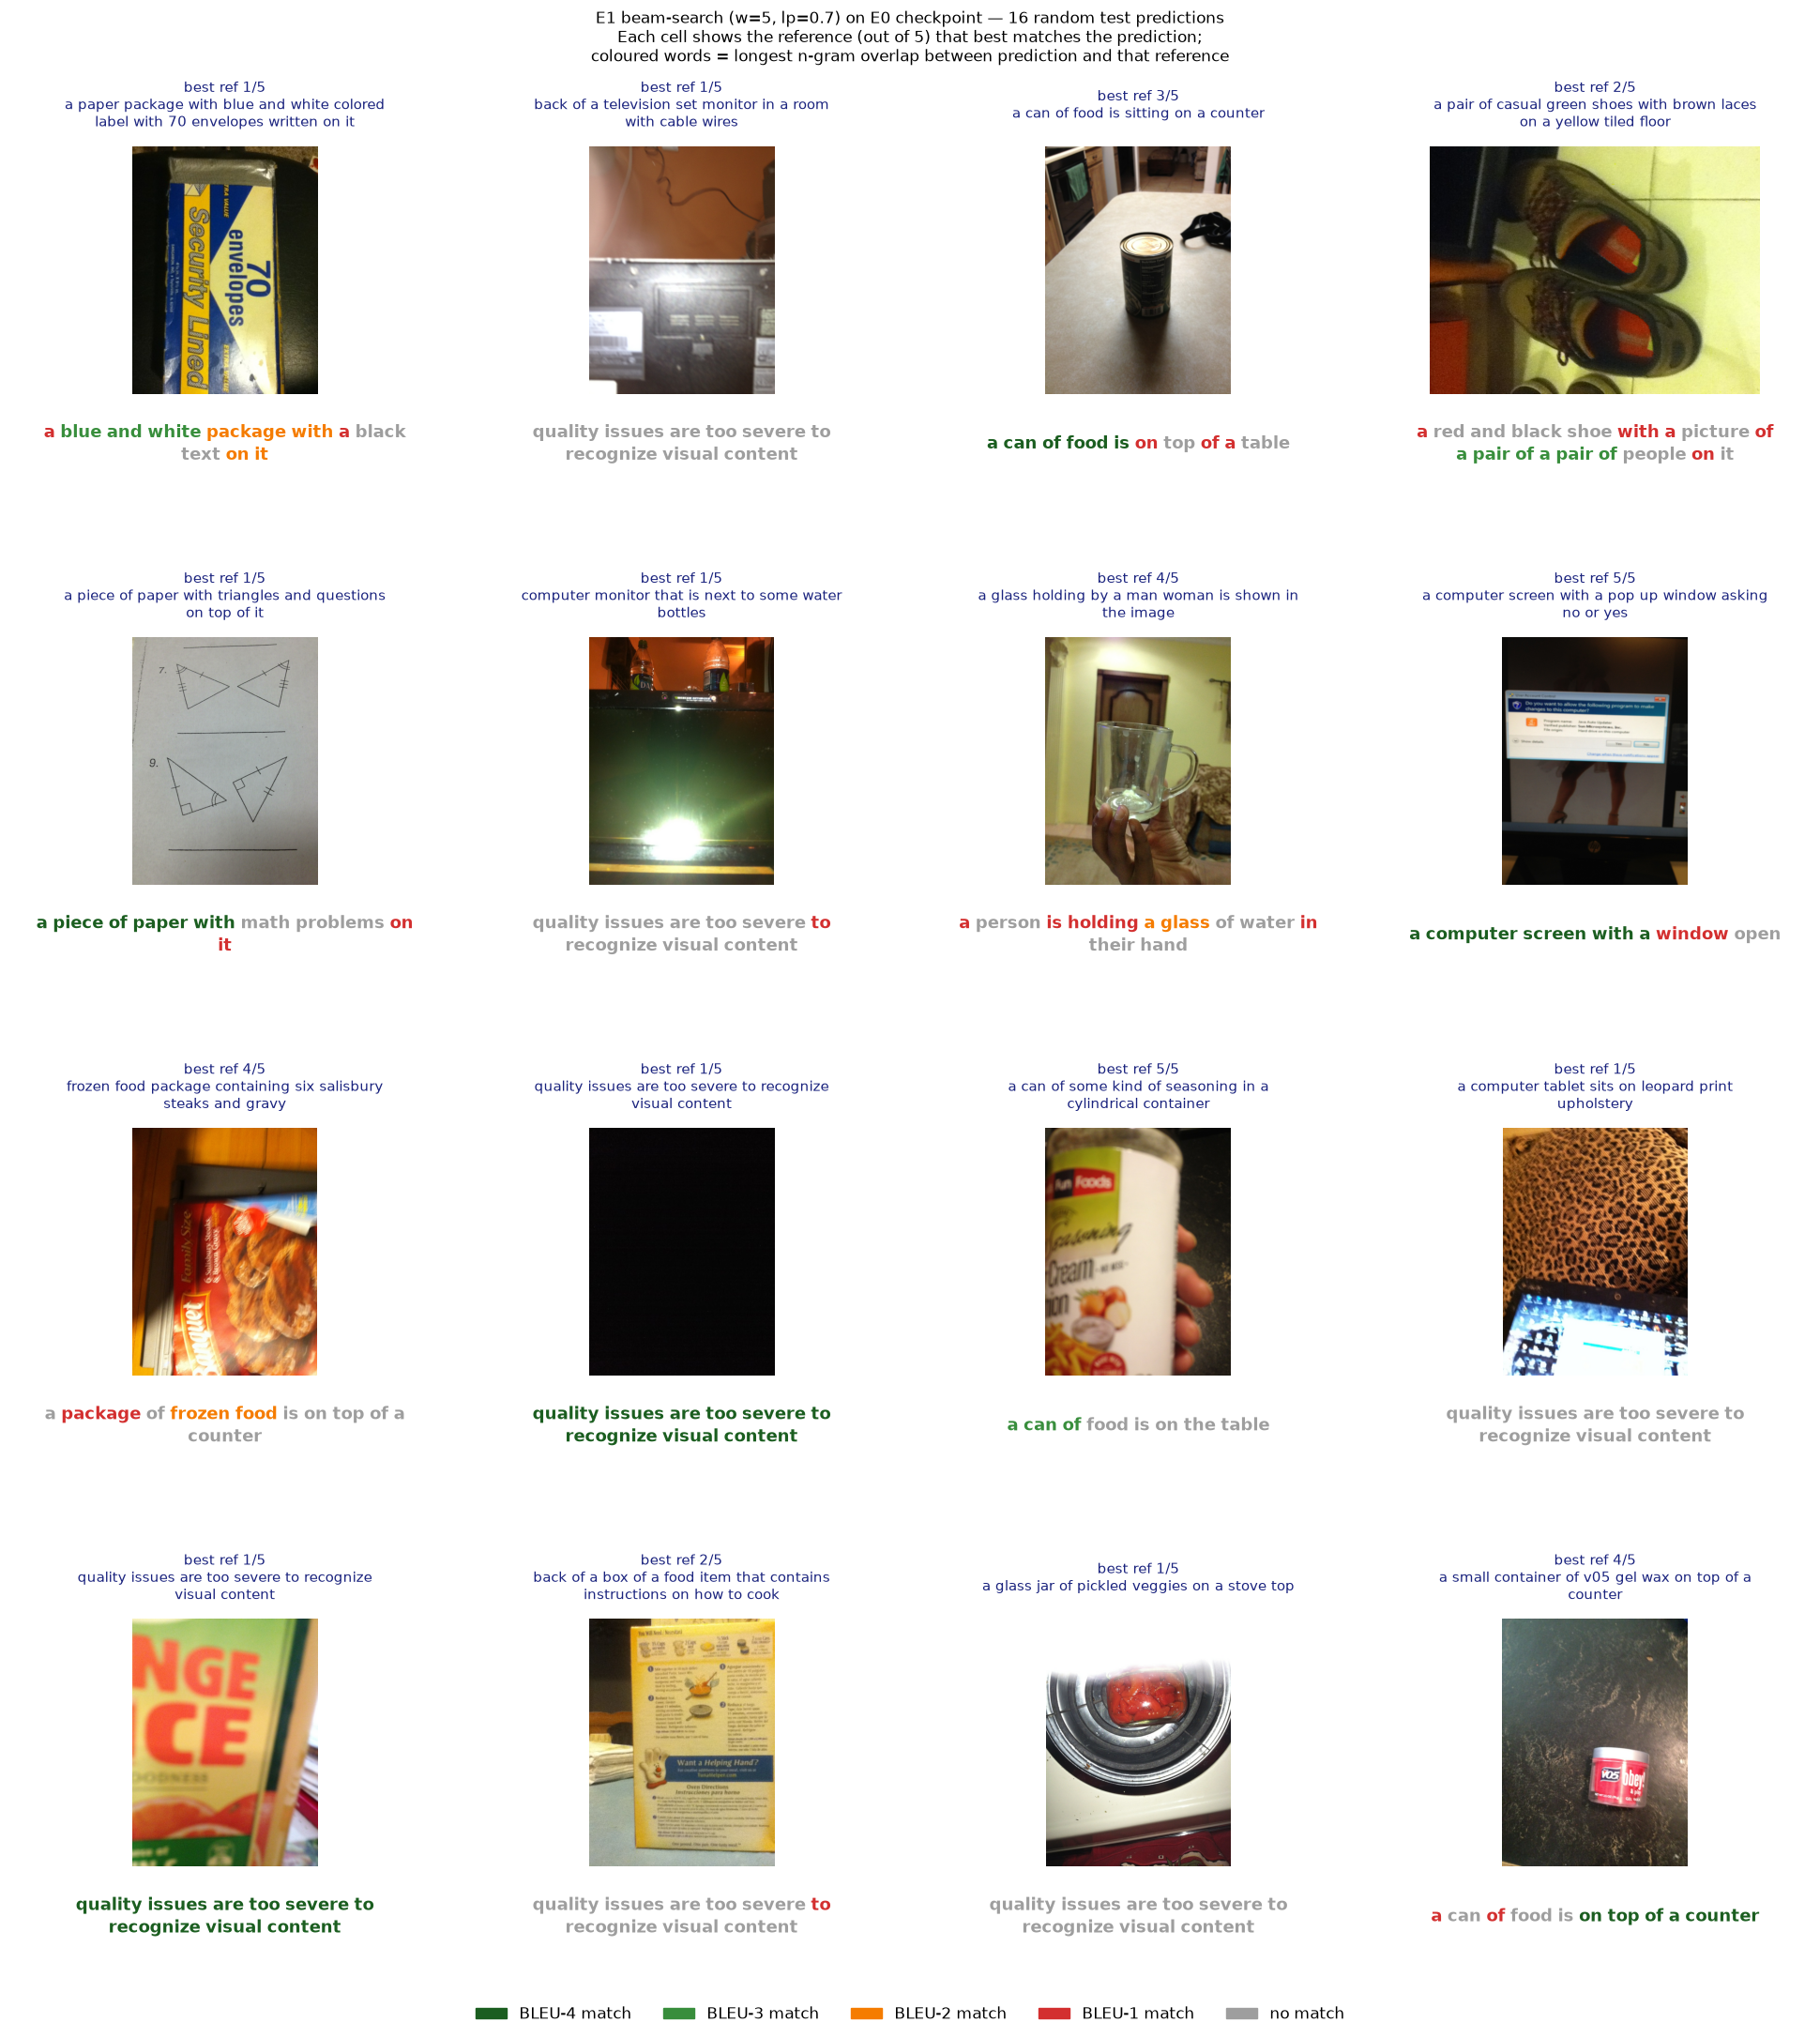

In [4]:
import matplotlib.gridspec as mgridspec
import matplotlib.patches as mpatches

random.seed(42)
sample = df.sample(n=16, random_state=42).reset_index(drop=True)

# Outer 4×4 grid; inside each cell a 3-row sub-grid: [reference, image, prediction].
fig = plt.figure(figsize=(20, 22))
outer = mgridspec.GridSpec(4, 4, figure=fig, hspace=0.18, wspace=0.06,
                           top=0.96, bottom=0.045, left=0.02, right=0.98)

def wrap_text_lines(text: str, width: int = 50) -> str:
    words = text.split()
    lines, cur = [], ""
    for w in words:
        if len(cur) + len(w) + 1 > width:
            lines.append(cur); cur = w
        else:
            cur = (cur + " " + w).strip()
    if cur:
        lines.append(cur)
    return "\n".join(lines)

for i, row in sample.iterrows():
    inner = mgridspec.GridSpecFromSubplotSpec(
        3, 1, subplot_spec=outer[i // 4, i % 4],
        height_ratios=[1.1, 4.0, 1.4], hspace=0.05,
    )
    ref_ax = fig.add_subplot(inner[0])
    img_ax = fig.add_subplot(inner[1])
    pred_ax = fig.add_subplot(inner[2])

    # --- Pick the best-matching reference (most n-gram overlap with prediction)
    # and restrict highlighting to that one — so every coloured word is verifiable
    # against the displayed reference.
    refs = row["references"]
    n_refs = len(refs)
    pred_words = str(row["prediction"]).split()
    ref_word_lists = [str(r).split() for r in refs]
    best_idx = best_reference_index(pred_words, ref_word_lists)
    chosen_ref = refs[best_idx]
    ref_ax.set_axis_off()
    ref_ax.text(
        0.5, 0.5,
        f"best ref {best_idx + 1}/{n_refs}\n{wrap_text_lines(chosen_ref, 45)}",
        ha="center", va="center", fontsize=11, color="#1a237e",
        transform=ref_ax.transAxes,
    )

    # --- Image (centered by imshow + equal aspect) ---
    img = Image.open(IMG_DIR / row["file_name"]).convert("RGB")
    img_ax.imshow(img)
    img_ax.set_xticks([]); img_ax.set_yticks([])
    for spine in img_ax.spines.values():
        spine.set_visible(False)

    # --- Prediction: highlight against only the chosen reference so every
    # coloured word is verifiable against what is shown above the image.
    levels = word_match_levels(pred_words, [ref_word_lists[best_idx]])
    colors = [LEVEL_COLOR[lv] for lv in levels]
    colored_words_centered(pred_ax, words=pred_words, colors=colors,
                           fontsize=13, max_chars_per_line=40)

# Legend
handles = [mpatches.Patch(color=LEVEL_COLOR[lv], label=f"BLEU-{lv} match" if lv else "no match")
           for lv in [4, 3, 2, 1, 0]]
fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=12,
           frameon=False, bbox_to_anchor=(0.5, 0.008))
fig.suptitle(
    "E1 beam-search (w=5, lp=0.7) on E0 checkpoint — 16 random test predictions\n"
    "Each cell shows the reference (out of 5) that best matches the prediction;\n"
    "coloured words = longest n-gram overlap between prediction and that reference",
    fontsize=12, y=0.99,
)
OUT_PNG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT_PNG, dpi=180, bbox_inches="tight")
print(f"Saved {OUT_PNG}")
plt.show()